# Chapter 6 — Cholesky factorization and iterative refinement

**Numerical Linear Algebra: Theory, Algorithms, and Computation**

**Abdallah Alsammani, Ph.D.**  
Department of Mathematical Sciences & Data Science  
Delaware State University

Lecture notes: <https://aalsammani.github.io/numerical-linear-algebra/>  
Notes for this chapter: <https://aalsammani.github.io/numerical-linear-algebra/ch06-cholesky/notes.html>  
Repository: <https://github.com/aalsammani/Numerical-Linear-Algebra-Notebooks>

This notebook is the computational laboratory of the chapter; the theory,
proofs and exercises are in the lecture notes, to which the links below
point. References such as Trefethen and Bau (1997) are listed in the
[bibliography of the notes](https://aalsammani.github.io/numerical-linear-algebra/back/bibliography.html). Version
1.0, September 2026.

---

This notebook accompanies [Chapter 6](https://aalsammani.github.io/numerical-linear-algebra/ch06-cholesky/notes.html#ch06) of the notes. Every
experiment checks a statement from the chapter numerically.

**Learning objectives.** After working through this lab you should be able to

1. build SPD test matrices (discrete Laplacians, Gaussian-process kernel
   matrices, matrices with prescribed condition number) and check their
   properties;
2. implement the column-oriented Cholesky algorithm with a stated symmetry
   convention, and use the NumPy and SciPy routines with the correct
   lower/upper conventions;
3. verify the entry bound $|\ell_{ij}|\le\sqrt{a_{ii}}$, the backward error
   bound, and the failure modes of Cholesky in floating point;
4. use $LDL^T$ with Bunch--Kaufman pivoting for symmetric indefinite matrices;
5. compute Gaussian log-likelihoods, samples and posterior means with the
   Cholesky factor, and control conditioning with a jitter;
6. run fixed-precision, low-precision and extra-precise iterative
   refinement and explain when each converges;
7. implement Hager's 1-norm condition estimator and compare it with LAPACK
   and SciPy.

Run the cells in order from a fresh kernel.

In [1]:
import math
import time
import warnings
from fractions import Fraction

import matplotlib.pyplot as plt
import numpy as np
import scipy
import scipy.linalg as sla
from scipy.sparse.linalg import LinearOperator, onenormest
from scipy.stats import multivariate_normal

rng = np.random.default_rng(20260927)
u = np.finfo(np.float64).eps / 2      # unit roundoff of binary64, 2**-53
u32 = np.finfo(np.float32).eps / 2    # unit roundoff of binary32, 2**-24
plt.rcParams.update({"figure.figsize": (6.4, 4.0), "axes.grid": True, "grid.alpha": 0.3})
print(f"NumPy {np.__version__}, SciPy {scipy.__version__}; u = {u:.3e}, u32 = {u32:.3e}")


def gamma(k, unit=u):
    """Higham's constant gamma_k = k u / (1 - k u)."""
    return k * unit / (1 - k * unit)

NumPy 2.5.3, SciPy 1.18.1; u = 1.110e-16, u32 = 5.960e-08


## 1. SPD test matrices

We use four families of symmetric positive definite matrices:

- the one-dimensional Laplacian $T_n = \operatorname{tridiag}(-1, 2, -1)$,
  whose eigenvalues are $4\sin^2(k\pi/(2(n+1)))$, $k = 1,\dots,n$;
- the two-dimensional Laplacian $I_m\otimes T_m + T_m\otimes I_m$ of order
  $n = m^2$;
- the squared-exponential kernel matrix
  $K_{ij} = \sigma_f^2\exp(-(t_i-t_j)^2/(2\ell^2))$;
- random matrices $Q\,\operatorname{diag}(\lambda)\,Q^T$ with eigenvalues
  spaced logarithmically between $1/\kappa$ and $1$, so that
  $\kappa_2 = \kappa$ (up to rounding).

In [2]:
def laplacian_1d(n):
    return 2.0 * np.eye(n) - np.eye(n, k=1) - np.eye(n, k=-1)


def laplacian_2d(m):
    T, I = laplacian_1d(m), np.eye(m)
    return np.kron(I, T) + np.kron(T, I)


def se_kernel(t, ell, sigma_f=1.0):
    d = t[:, None] - t[None, :]
    return sigma_f**2 * np.exp(-d**2 / (2 * ell**2))


def random_spd(n, kappa, rng):
    """Q diag(lambda) Q^T with log-spaced eigenvalues in [1/kappa, 1]."""
    Q, _ = np.linalg.qr(rng.standard_normal((n, n)))
    lam = np.logspace(0, -np.log10(kappa), n)
    A = (Q * lam) @ Q.T
    return (A + A.T) / 2          # exactly symmetric


n = 30
T = laplacian_1d(n)
lam_formula = 4 * np.sin(np.arange(1, n + 1) * np.pi / (2 * (n + 1)))**2
lam_computed = np.linalg.eigvalsh(T)
print(f"T_{n}: max |eigenvalue - formula| = {np.max(np.abs(lam_computed - np.sort(lam_formula))):.1e}, "
      f"kappa_2 = {lam_computed[-1] / lam_computed[0]:.1f}")
# eigvalsh is backward stable: each eigenvalue is accurate to a modest multiple of n u ||T||_2 (||T||_2 < 4).
assert np.max(np.abs(lam_computed - np.sort(lam_formula))) < 10 * n * u * 4

for name, A in [("T_30", T), ("2D Laplacian, m = 8", laplacian_2d(8)),
                ("random SPD, kappa = 1e6", random_spd(50, 1e6, rng)),
                ("SE kernel + 1e-6 I", se_kernel(np.linspace(0, 1, 40), 0.2) + 1e-6 * np.eye(40))]:
    d = np.diag(A)
    ratio = np.abs(A) / np.sqrt(np.outer(d, d))
    np.fill_diagonal(ratio, 0.0)
    lam = np.linalg.eigvalsh(A)
    print(f"{name:25s} symmetric: {np.array_equal(A, A.T)}, min diag = {d.min():.2e}, "
          f"max |a_ij|/sqrt(a_ii a_jj) (i != j) = {ratio.max():.3f}, min eigenvalue = {lam[0]:.2e}")
    assert np.array_equal(A, A.T) and d.min() > 0 and ratio.max() < 1

T_30: max |eigenvalue - formula| = 1.8e-15, kappa_2 = 388.8
T_30                      symmetric: True, min diag = 2.00e+00, max |a_ij|/sqrt(a_ii a_jj) (i != j) = 0.500, min eigenvalue = 1.03e-02
2D Laplacian, m = 8       symmetric: True, min diag = 4.00e+00, max |a_ij|/sqrt(a_ii a_jj) (i != j) = 0.250, min eigenvalue = 2.41e-01
random SPD, kappa = 1e6   symmetric: True, min diag = 2.41e-02, max |a_ij|/sqrt(a_ii a_jj) (i != j) = 0.880, min eigenvalue = 1.00e-06
SE kernel + 1e-6 I        symmetric: True, min diag = 1.00e+00, max |a_ij|/sqrt(a_ii a_jj) (i != j) = 0.992, min eigenvalue = 1.00e-06


All four matrices have a positive diagonal and satisfy
$|a_{ij}|<\sqrt{a_{ii}a_{jj}}$, as [Proposition 6.1](https://aalsammani.github.io/numerical-linear-algebra/ch06-cholesky/notes.html#ch06-prop-spd-properties)
requires. For the kernel matrix the computed smallest eigenvalue is close
to the jitter $10^{-6}$ that we added; without it, the matrix would be
numerically singular (Section 8).

## 2. Cholesky from scratch

We implement [Algorithm 6.1](https://aalsammani.github.io/numerical-linear-algebra/ch06-cholesky/notes.html#ch06-alg-cholesky). The inner loop over rows is a
single matrix-vector product. The function states its convention for
symmetry: it rejects matrices that are not symmetric up to rounding errors,
and otherwise reads only the lower triangle.

In [3]:
def cholesky(A, symmetry_tol=None):
    """Return the lower triangular L with A = L L^T (column-oriented algorithm).

    Convention: A must be symmetric up to rounding errors,
    max|a_ij - a_ji| <= symmetry_tol * max|a_ij| with default symmetry_tol = 10 n u;
    otherwise ValueError is raised. Only the lower triangle of A is read.
    Raises numpy.linalg.LinAlgError if a pivot d <= 0 (A is not positive definite).
    """
    A = np.asarray(A, dtype=float)
    n = A.shape[0]
    if A.ndim != 2 or A.shape[1] != n:
        raise ValueError("A must be square")
    tol = 10 * n * u if symmetry_tol is None else symmetry_tol
    if n > 0 and np.max(np.abs(A - A.T)) > tol * np.max(np.abs(A)):
        raise ValueError("A is not symmetric; symmetrize explicitly, e.g. (A + A.T) / 2")
    L = np.zeros_like(A)
    for j in range(n):
        d = A[j, j] - L[j, :j] @ L[j, :j]
        if not d > 0:                                   # also catches NaN
            raise np.linalg.LinAlgError(f"not positive definite: pivot {j + 1} is {d:.3e}")
        L[j, j] = np.sqrt(d)
        L[j + 1:, j] = (A[j + 1:, j] - L[j + 1:, :j] @ L[j, :j]) / L[j, j]
    return L

**The worked example.** [Example 6.2](https://aalsammani.github.io/numerical-linear-algebra/ch06-cholesky/notes.html#ch06-exa-cholesky-3x3) has integer data
and an integer factor, and every intermediate quantity is an exactly
representable integer, so the computation is exact.

In [4]:
A_ex = np.array([[1.0, 1.0, 0.0], [1.0, 2.0, 2.0], [0.0, 2.0, 5.0]])
b_ex = np.array([2.0, 5.0, 7.0])
L_ex = cholesky(A_ex)
y_ex = sla.solve_triangular(L_ex, b_ex, lower=True)
x_ex = sla.solve_triangular(L_ex.T, y_ex, lower=False)
print("L =\n", L_ex, "\ny =", y_ex, " x =", x_ex, " det A =", np.prod(np.diag(L_ex))**2)
assert np.array_equal(L_ex, [[1, 0, 0], [1, 1, 0], [0, 2, 1]])
assert np.array_equal(y_ex, [2, 3, 1]) and np.array_equal(x_ex, [1, 1, 1])

L =
 [[1. 0. 0.]
 [1. 1. 0.]
 [0. 2. 1.]] 
y = [2. 3. 1.]  x = [1. 1. 1.]  det A = 1.0


**Library conventions.** NumPy returns the lower factor $L$; SciPy's
`cholesky` returns the upper factor $R = L^T$ unless `lower=True`;
`cho_factor` returns a pair `(c, lower)` meant for `cho_solve`.

In [5]:
A = random_spd(200, 1e4, rng)
L_mine = cholesky(A)
L_np = np.linalg.cholesky(A)                 # lower: A = L L^T
R_sp = sla.cholesky(A)                       # upper: A = R^T R
L_sp = sla.cholesky(A, lower=True)
c, lower = sla.cho_factor(A)                 # (c, False): factor in the upper triangle of c
print(f"numpy lower triangular: {np.allclose(L_np, np.tril(L_np))}; "
      f"scipy default upper triangular: {np.allclose(R_sp, np.triu(R_sp))}; cho_factor lower = {lower}")

kappa, n = np.linalg.cond(A), A.shape[0]
# First-order perturbation theory for the Cholesky factor bounds the relative change in L by about
# kappa_2(A) times the relative backward error, which is O(n u) for each computed factor.
tol_factor = 10 * n * kappa * u
for name, L in [("numpy", L_np), ("scipy lower", L_sp), ("scipy upper^T", R_sp.T), ("cho_factor", np.triu(c).T)]:
    diff = np.linalg.norm(L_mine - L, "fro") / np.linalg.norm(L, "fro")
    print(f"||L_mine - L_{name}||_F / ||L||_F = {diff:.1e}")
    assert diff < tol_factor

numpy lower triangular: True; scipy default upper triangular: True; cho_factor lower = False
||L_mine - L_numpy||_F / ||L||_F = 6.0e-15
||L_mine - L_scipy lower||_F / ||L||_F = 5.8e-15
||L_mine - L_scipy upper^T||_F / ||L||_F = 6.0e-15
||L_mine - L_cho_factor||_F / ||L||_F = 6.0e-15


The warning in the SciPy documentation about the unused triangle of `c` is
real: with `overwrite_a=True`, the lower triangle of `c` still holds the
original entries of $A$, so `c` itself is not the factor.

In [6]:
A_copy = A.copy()
c_ow, _ = sla.cho_factor(A_copy, overwrite_a=True)
print(f"max |entry| strictly below the diagonal of c: {np.max(np.abs(np.tril(c_ow, -1))):.3e} "
      f"(the upper factor is in np.triu(c))")
x_true = rng.standard_normal(200)
b = A @ x_true
x_cs = sla.cho_solve((c, lower), b)
print(f"cho_solve relative residual: {np.linalg.norm(b - A @ x_cs) / (np.linalg.norm(A, 2) * np.linalg.norm(x_cs)):.1e}")

max |entry| strictly below the diagonal of c: 7.371e-02 (the upper factor is in np.triu(c))
cho_solve relative residual: 1.0e-16


**Backward error.** By [Corollary 6.1](https://aalsammani.github.io/numerical-linear-algebra/ch06-cholesky/notes.html#ch06-cor-normwise),
$\|A - \widehat L\widehat L^T\|_2\le n\gamma_{n+1}\|A\|_2/(1-\gamma_{n+1})$.
We check this bound for our implementation and for LAPACK on several
matrices.

In [7]:
for name, A in [("2D Laplacian m=15", laplacian_2d(15)), ("random SPD kappa=1e8", random_spd(300, 1e8, rng)),
                ("SE kernel + 1e-8 I", se_kernel(np.linspace(0, 1, 300), 0.1) + 1e-8 * np.eye(300))]:
    n = A.shape[0]
    bound = n * gamma(n + 1) / (1 - gamma(n + 1))
    nA = np.linalg.norm(A, 2)
    for impl, L in [("mine", cholesky(A)), ("LAPACK", np.linalg.cholesky(A))]:
        be = np.linalg.norm(A - L @ L.T, 2) / nA
        print(f"{name:22s} {impl:6s}: ||A - LL^T||_2/||A||_2 = {be:.2e} = {be / u:5.2f} u   (bound {bound:.1e})")
        assert be <= bound

2D Laplacian m=15      mine  : ||A - LL^T||_2/||A||_2 = 1.23e-16 =  1.11 u   (bound 5.6e-12)
2D Laplacian m=15      LAPACK: ||A - LL^T||_2/||A||_2 = 1.40e-16 =  1.26 u   (bound 5.6e-12)
random SPD kappa=1e8   mine  : ||A - LL^T||_2/||A||_2 = 1.79e-16 =  1.62 u   (bound 1.0e-11)
random SPD kappa=1e8   LAPACK: ||A - LL^T||_2/||A||_2 = 5.81e-17 =  0.52 u   (bound 1.0e-11)
SE kernel + 1e-8 I     mine  : ||A - LL^T||_2/||A||_2 = 5.81e-17 =  0.52 u   (bound 1.0e-11)
SE kernel + 1e-8 I     LAPACK: ||A - LL^T||_2/||A||_2 = 4.84e-17 =  0.44 u   (bound 1.0e-11)


The observed backward errors are a small multiple of $u$, far below the
worst-case bound $n\gamma_{n+1}\approx n^2u$, and independent of the
conditioning of $A$.

## 3. The entry bound, and a false bound

Row $i$ of $A = LL^T$ gives $a_{ii} = \sum_{k\le i}\ell_{ik}^2$, hence
$|\ell_{ij}|\le\sqrt{a_{ii}}$ ([Proposition 6.3](https://aalsammani.github.io/numerical-linear-algebra/ch06-cholesky/notes.html#ch06-prop-entry-bound)). An earlier
version of these notes claimed $|\ell_{ij}|\le\ell_{jj}$ instead. We test
both on 200 random SPD matrices with widely varying diagonal scaling.

In [8]:
violations_false, violations_true, entries = 0, 0, 0
for trial in range(200):
    n = int(rng.integers(3, 21))
    B = rng.standard_normal((n, n))
    D = np.diag(10.0 ** rng.uniform(-1, 1, n))
    A = D @ (B @ B.T / n + 0.1 * np.eye(n)) @ D
    A = (A + A.T) / 2
    L = np.linalg.cholesky(A)
    i, j = np.tril_indices(n, -1)
    entries += len(i)
    violations_false += int(np.sum(np.abs(L[i, j]) > L[j, j]))
    # computed factor: sum_k l_ik^2 = a_ii (1 + O(n u)), so allow a relative slack of 10 n u
    violations_true += int(np.sum(np.abs(L) > np.sqrt(np.diag(A))[:, None] * (1 + 10 * n * u)))
print(f"{entries} subdiagonal entries: |l_ij| > l_jj in {violations_false} cases; "
      f"|l_ij| > sqrt(a_ii) in {violations_true} cases")
assert violations_true == 0 and violations_false > 0

15218 subdiagonal entries: |l_ij| > l_jj in 2858 cases; |l_ij| > sqrt(a_ii) in 0 cases


The false bound fails many times; the true bound never does. The smallest
counterexample is $\begin{bmatrix}1&2\\2&5\end{bmatrix}$, whose factor
$\begin{bmatrix}1&0\\2&1\end{bmatrix}$ has $\ell_{21} = 2>\ell_{11} = 1$.

## 4. When Cholesky fails

**Indefinite input.** For the symmetric matrix
$\begin{bmatrix}1&2\\2&1\end{bmatrix}$ (eigenvalues $3$ and $-1$) the second
pivot is $1 - 2^2 = -3$. The vector $z$ of [Theorem 6.5](https://aalsammani.github.io/numerical-linear-algebra/ch06-cholesky/notes.html#ch06-thm-test-pd)
certifies indefiniteness.

In [9]:
A_ind = np.array([[1.0, 2.0], [2.0, 1.0]])
for f in (cholesky, np.linalg.cholesky):
    try:
        f(A_ind)
        print(f"{f.__module__}.{f.__name__}: succeeded (wrong!)")
    except np.linalg.LinAlgError as err:
        print(f"{f.__module__}.{f.__name__}: LinAlgError: {err}")
z = np.array([-A_ind[0, 1] / A_ind[0, 0], 1.0])
print("certificate z =", z, " z^T A z =", z @ A_ind @ z)
assert z @ A_ind @ z == -3.0

__main__.cholesky: LinAlgError: not positive definite: pivot 2 is -3.000e+00
numpy.linalg.cholesky: LinAlgError: Matrix is not positive definite
certificate z = [-2.  1.]  z^T A z = -3.0


**Nonsymmetric input.** LAPACK reads one triangle and does not check
symmetry. NumPy reads the lower triangle, so it "succeeds" on the
nonsymmetric matrix below and returns the factor of a different matrix;
SciPy reads the upper triangle by default, which here happens to form an
indefinite matrix, so it fails. Our implementation rejects the input.

In [10]:
A_ns = np.array([[4.0, 3.0], [1.0, 2.0]])
L_ns = np.linalg.cholesky(A_ns)
print("numpy.linalg.cholesky returned L with L L^T =\n", L_ns @ L_ns.T, "\nwhich is not A =\n", A_ns)
try:
    cholesky(A_ns)
except ValueError as err:
    print("our cholesky:", err)
try:
    sla.cholesky(A_ns)                     # reads the upper triangle: [[4, 3], [3, 2]] is indefinite
except np.linalg.LinAlgError as err:
    print("scipy.linalg.cholesky (upper triangle):", err)
assert np.allclose(L_ns @ L_ns.T, [[4, 1], [1, 2]])

numpy.linalg.cholesky returned L with L L^T =
 [[4. 1.]
 [1. 2.]] 
which is not A =
 [[4. 3.]
 [1. 2.]]
our cholesky: A is not symmetric; symmetrize explicitly, e.g. (A + A.T) / 2
scipy.linalg.cholesky (upper triangle): Internal potrf return info = [2] for slices [0].


**Nearly singular SPD matrices.** The Hilbert matrix $H_n$ is SPD for every
$n$, but its smallest eigenvalue decays so fast that for $n = 14$ it is far
below the rounding errors in the stored entries. To decide whether the
*stored* matrix $\operatorname{fl}(H_n)$ is positive definite, we compute the
pivots of its $LDL^T$ factorization exactly, in rational arithmetic
(every double is a rational number).

In [11]:
def exact_ldl_pivots(A):
    """Pivots d_k of the LDL^T factorization of the stored matrix, in exact rational arithmetic."""
    n = A.shape[0]
    M = [[Fraction(float(A[i, j])) for j in range(n)] for i in range(n)]
    pivots = []
    for k in range(n):
        p = M[k][k]
        pivots.append(p)
        if p == 0:
            break
        for i in range(k + 1, n):
            f = M[i][k] / p
            for j in range(k + 1, n):
                M[i][j] -= f * M[k][j]
    return pivots


for n in (12, 13, 14):
    H = sla.hilbert(n)
    try:
        np.linalg.cholesky(H)
        outcome = "succeeds"
    except np.linalg.LinAlgError:
        outcome = "fails"
    piv = exact_ldl_pivots(H)
    print(f"n = {n}: numpy Cholesky {outcome:8s}; stored matrix positive definite (exact test): "
          f"{all(p > 0 for p in piv)}; smallest exact pivot = {float(min(piv)):.2e}")

n = 12: numpy Cholesky succeeds; stored matrix positive definite (exact test): True; smallest exact pivot = 8.88e-14
n = 13: numpy Cholesky succeeds; stored matrix positive definite (exact test): True; smallest exact pivot = 1.39e-15
n = 14: numpy Cholesky fails   ; stored matrix positive definite (exact test): False; smallest exact pivot = -1.01e-13


For $n = 14$ the exact computation finds a negative pivot: the double
precision matrix that Cholesky receives is indefinite, so the failure is
the correct answer ([Example 6.3](https://aalsammani.github.io/numerical-linear-algebra/ch06-cholesky/notes.html#ch06-exa-hilbert)). SciPy's `solve` warns
before this point, because its condition estimate (Section 10) shows that
$H_{12}$ is already singular to working precision.

In [12]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    sla.solve(sla.hilbert(12), np.ones(12), assume_a="pos")
print([str(w.message) for w in caught])

['An ill-conditioned matrix detected: slice 0 has rcond = 2.5560824980624142e-17.']


## 5. Backward stability versus accuracy

[Theorem 6.4](https://aalsammani.github.io/numerical-linear-algebra/ch06-cholesky/notes.html#ch06-thm-solve-backward) says that the computed solution has a
backward error of order $u$ and hence a forward error of at most about
$\kappa_2(A)u$ (times a dimensional constant). We check both on matrices
with prescribed condition numbers.

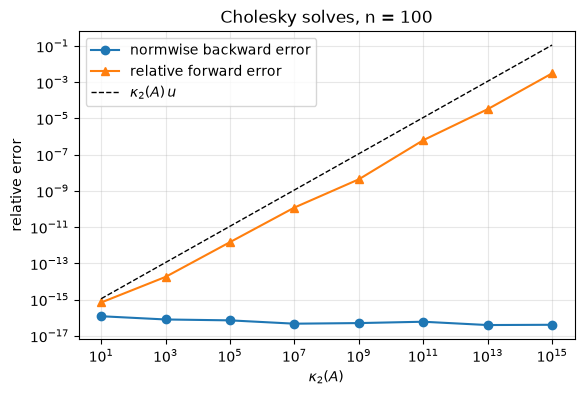

In [13]:
n = 100
kappas = np.logspace(1, 15, 8)
back, fwd = [], []
for kappa in kappas:
    A = random_spd(n, kappa, rng)
    x = rng.standard_normal(n)
    b = A @ x
    xh = sla.cho_solve(sla.cho_factor(A), b)
    back.append(np.linalg.norm(b - A @ xh) / (np.linalg.norm(A, 2) * np.linalg.norm(xh)))
    fwd.append(np.linalg.norm(xh - x) / np.linalg.norm(x))
    # (A + dA) xh = b with ||dA||_2 <= n gamma_{3n+1} ||A||_2 / (1 - gamma_{n+1});
    # b itself carries a rounding error of at most gamma_n |A||x|, which is covered by a factor 2.
    bound = 2 * n * gamma(3 * n + 1) / (1 - gamma(n + 1))
    assert back[-1] <= bound and fwd[-1] <= kappa * bound

fig, ax = plt.subplots()
ax.loglog(kappas, back, "o-", label="normwise backward error")
ax.loglog(kappas, fwd, "^-", label="relative forward error")
ax.loglog(kappas, kappas * u, "k--", lw=1, label=r"$\kappa_2(A)\,u$")
ax.set_xlabel(r"$\kappa_2(A)$")
ax.set_ylabel("relative error")
ax.set_title(f"Cholesky solves, n = {n}")
ax.legend()
plt.show()

The backward error stays at the level of $u$ for every condition number,
while the forward error grows in proportion to $\kappa_2(A)$: backward
stability is a property of the algorithm, accuracy a property of the
algorithm and the problem together.

## 6. Timing: Cholesky versus LU

Cholesky needs $\tfrac13n^3$ flops and LU $\tfrac23n^3$. We time LAPACK's
`?potrf` (via `cho_factor`) and `?getrf` (via `lu_factor`) on the same SPD
matrices, taking the median of several repeats after a warm-up call. We
also time `scipy.linalg.lu`, which in addition forms the explicit matrices
$P$, $L$ and $U$; the earlier version of this lab compared against it.

n =  250: cho_factor     0.58 ms, lu_factor     1.52 ms (ratio 2.6), scipy.linalg.lu     1.76 ms (ratio 3.0)


n =  500: cho_factor     1.77 ms, lu_factor    50.73 ms (ratio 28.7), scipy.linalg.lu    56.25 ms (ratio 31.8)


n = 1000: cho_factor    10.14 ms, lu_factor    47.96 ms (ratio 4.7), scipy.linalg.lu    75.00 ms (ratio 7.4)


n = 2000: cho_factor    42.36 ms, lu_factor   147.90 ms (ratio 3.5), scipy.linalg.lu   180.91 ms (ratio 4.3)


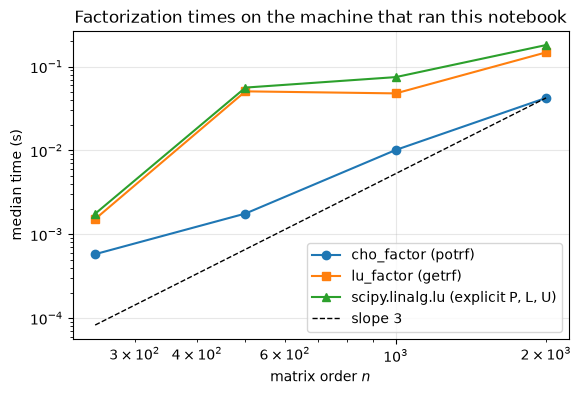

In [14]:
def median_time(f, *args, repeats=7):
    f(*args)                                   # warm-up
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        f(*args)
        times.append(time.perf_counter() - t0)
    return float(np.median(times))


sizes = [250, 500, 1000, 2000]
t_chol, t_lu, t_lu_full = [], [], []
for n in sizes:
    B = rng.standard_normal((n, n))
    A = B @ B.T + n * np.eye(n)
    t_chol.append(median_time(sla.cho_factor, A))
    t_lu.append(median_time(sla.lu_factor, A))
    t_lu_full.append(median_time(sla.lu, A, repeats=3))
    print(f"n = {n:4d}: cho_factor {t_chol[-1] * 1e3:8.2f} ms, lu_factor {t_lu[-1] * 1e3:8.2f} ms "
          f"(ratio {t_lu[-1] / t_chol[-1]:.1f}), scipy.linalg.lu {t_lu_full[-1] * 1e3:8.2f} ms "
          f"(ratio {t_lu_full[-1] / t_chol[-1]:.1f})")

fig, ax = plt.subplots()
ax.loglog(sizes, t_chol, "o-", label="cho_factor (potrf)")
ax.loglog(sizes, t_lu, "s-", label="lu_factor (getrf)")
ax.loglog(sizes, t_lu_full, "^-", label="scipy.linalg.lu (explicit P, L, U)")
ref = np.array(sizes, dtype=float)
ax.loglog(ref, t_chol[-1] * (ref / ref[-1])**3, "k--", lw=1, label=r"slope 3")
ax.set_xlabel("matrix order $n$")
ax.set_ylabel("median time (s)")
ax.set_title("Factorization times on the machine that ran this notebook")
ax.legend()
plt.show()

**Interpretation.** The flop ratio of LU to Cholesky is 2. The measured
ratios printed above are observations about this machine, its BLAS
library, its number of cores and its load while the notebook ran, not
properties of the algorithms, and they need not be close to 2: LU also
searches for pivots and swaps rows, and the two blocked routines are
parallelized differently (multithreaded LU can be particularly sensitive
to other work running on the machine). `scipy.linalg.lu` additionally
forms explicit $P$, $L$ and $U$ matrices, so timing it measures more than
the factorization; the earlier version of this lab made that comparison
and printed ratios of 6 to 7 next to the unexplained remark "theory
predicts ~2x". The only machine-independent prediction is the flop count.

## 7. Symmetric indefinite matrices: $LDL^T$ with Bunch--Kaufman pivoting

`scipy.linalg.ldl` returns `(lu, d, perm)` with $A = \texttt{lu}\,D\,\texttt{lu}^T$,
where `lu[perm]` is unit lower triangular and $D$ is block diagonal with
blocks of order 1 and 2 ([Algorithm 6.2](https://aalsammani.github.io/numerical-linear-algebra/ch06-cholesky/notes.html#ch06-alg-bunch-kaufman)). We look at the
two matrices of [Example 6.4](https://aalsammani.github.io/numerical-linear-algebra/ch06-cholesky/notes.html#ch06-exa-indefinite).

In [15]:
for eps in (1e-8, 0.0):
    A2 = np.array([[eps, 1.0], [1.0, 1.0 if eps else 0.0]])
    lu_f, d_f, perm = sla.ldl(A2)
    print(f"A = {A2.tolist()}:\n  lu[perm] = {lu_f[perm].tolist()}\n  D = {d_f.tolist()}")
    assert np.allclose(lu_f @ d_f @ lu_f.T, A2, atol=4 * u)

A = [[1e-08, 1.0], [1.0, 1.0]]:
  lu[perm] = [[1.0, 0.0], [1.0, 1.0]]
  D = [[1.0, 0.0], [0.0, -0.99999999]]
A = [[0.0, 1.0], [1.0, 0.0]]:
  lu[perm] = [[1.0, 0.0], [0.0, 1.0]]
  D = [[0.0, 1.0], [1.0, 0.0]]


For $\epsilon = 10^{-8}$ the rows and columns are interchanged and the pivot
is $a_{22} = 1$, so all entries of the factors are of size 1. For the matrix
with zero diagonal, $D$ is the whole matrix, a single $2\times2$ block.

**Inertia.** By Sylvester's law of inertia, $A$ and $D$ have the same numbers
of positive and negative eigenvalues ([Remark 6.1](https://aalsammani.github.io/numerical-linear-algebra/ch06-cholesky/notes.html#ch06-rem-inertia)). We count
them from the blocks of $D$ for a random symmetric matrix, and use the same
idea to count the eigenvalues of $T_n$ below a shift $\sigma$.

In [16]:
def inertia_from_ldl(A):
    """(number of positive, number of negative) eigenvalues of symmetric A, from its LDL^T factorization."""
    _, D, _ = sla.ldl(A)
    n, k, pos, neg = A.shape[0], 0, 0, 0
    while k < n:
        if k + 1 < n and D[k + 1, k] != 0:           # 2x2 block: one positive, one negative eigenvalue
            ev = np.linalg.eigvalsh(D[k:k + 2, k:k + 2])
            pos, neg, k = pos + int(np.sum(ev > 0)), neg + int(np.sum(ev < 0)), k + 2
        else:
            pos, neg, k = pos + int(D[k, k] > 0), neg + int(D[k, k] < 0), k + 1
    return pos, neg


S = rng.standard_normal((300, 300))
S = S + S.T
ev = np.linalg.eigvalsh(S)
print("inertia from LDL^T:", inertia_from_ldl(S), " from eigenvalues:", (int(np.sum(ev > 0)), int(np.sum(ev < 0))))
assert inertia_from_ldl(S) == (int(np.sum(ev > 0)), int(np.sum(ev < 0)))

n = 50
lam_T = 4 * np.sin(np.arange(1, n + 1) * np.pi / (2 * (n + 1)))**2
for sigma in (0.5, 1.0, 2.5):
    _, neg = inertia_from_ldl(laplacian_1d(n) - sigma * np.eye(n))
    print(f"eigenvalues of T_{n} below {sigma}: {neg} (from LDL^T of T - sigma I), {int(np.sum(lam_T < sigma))} (formula)")
    assert neg == int(np.sum(lam_T < sigma))

x = rng.standard_normal(300)
b = S @ x
xs = sla.solve(S, b, assume_a="sym")                  # Bunch-Kaufman solve
print(f"symmetric indefinite solve: backward error {np.linalg.norm(b - S @ xs) / (np.linalg.norm(S, 2) * np.linalg.norm(xs)) / u:.1f} u")

inertia from LDL^T: (150, 150)  from eigenvalues: (150, 150)
eigenvalues of T_50 below 0.5: 11 (from LDL^T of T - sigma I), 11 (formula)
eigenvalues of T_50 below 1.0: 16 (from LDL^T of T - sigma I), 16 (formula)
eigenvalues of T_50 below 2.5: 29 (from LDL^T of T - sigma I), 29 (formula)
symmetric indefinite solve: backward error 25.3 u


## 8. Gaussian distributions and Gaussian processes

**Kernel matrices need jitter.** The squared-exponential kernel matrix on 200
equispaced points is SPD in exact arithmetic, but most of its eigenvalues
are below the rounding errors, and Cholesky fails. Adding $\sigma^2I$ makes
it factorizable, and [Proposition 6.5](https://aalsammani.github.io/numerical-linear-algebra/ch06-cholesky/notes.html#ch06-prop-jitter) bounds the resulting
condition number by $1 + n\sigma_f^2/\sigma^2$.

In [17]:
n = 200
t = np.linspace(0, 1, n)
K = se_kernel(t, 0.1)
ev = np.linalg.eigvalsh(K)
print(f"computed eigenvalues: largest {ev[-1]:.2f}, {np.sum(ev < 0)} negative, smallest {ev[0]:.1e}")
try:
    np.linalg.cholesky(K)
    print("Cholesky of K succeeded")
except np.linalg.LinAlgError:
    print("Cholesky of K fails")
for s2 in (1e-12, 1e-10, 1e-8, 1e-6, 1e-4):
    Kj = K + s2 * np.eye(n)
    np.linalg.cholesky(Kj)                              # succeeds
    kap = np.linalg.cond(Kj)
    print(f"jitter {s2:.0e}: kappa_2 = {kap:.2e}, bound 1 + n/sigma^2 = {1 + n / s2:.2e}")
    assert kap <= 1 + n / s2

computed eigenvalues: largest 47.96, 84 negative, smallest -8.2e-15
Cholesky of K fails
jitter 1e-12: kappa_2 = 4.85e+13, bound 1 + n/sigma^2 = 2.00e+14
jitter 1e-10: kappa_2 = 4.80e+11, bound 1 + n/sigma^2 = 2.00e+12
jitter 1e-08: kappa_2 = 4.80e+09, bound 1 + n/sigma^2 = 2.00e+10
jitter 1e-06: kappa_2 = 4.80e+07, bound 1 + n/sigma^2 = 2.00e+08
jitter 1e-04: kappa_2 = 4.80e+05, bound 1 + n/sigma^2 = 2.00e+06


**Log-likelihood.** For noisy observations $y = f(t) + \varepsilon$ with
$\varepsilon\sim N(0,\sigma_n^2I)$, the log marginal likelihood is
[(6.3)](https://aalsammani.github.io/numerical-linear-algebra/ch06-cholesky/notes.html#equation-ch06-eq-loglik) with $K_y = K + \sigma_n^2I$. We evaluate it with the
Cholesky factor ([Proposition 6.4](https://aalsammani.github.io/numerical-linear-algebra/ch06-cholesky/notes.html#ch06-prop-gaussian)) and compare with
`slogdet` plus a linear solve, and with SciPy's `multivariate_normal`.

In [18]:
def gp_loglik(K_y, y):
    """Log density of N(0, K_y) at y via the Cholesky factor: -1/2 |z|^2 - sum log l_ii - n/2 log(2 pi)."""
    L = np.linalg.cholesky(K_y)
    z = sla.solve_triangular(L, y, lower=True)
    return -0.5 * z @ z - np.sum(np.log(np.diag(L))) - 0.5 * len(y) * np.log(2 * np.pi)


sigma_n2 = 0.01
f_true = np.sin(2 * np.pi * t)
y = f_true + np.sqrt(sigma_n2) * rng.standard_normal(n)
K_y = K + sigma_n2 * np.eye(n)
ll_chol = gp_loglik(K_y, y)
sign, logdet = np.linalg.slogdet(K_y)
ll_slog = -0.5 * y @ np.linalg.solve(K_y, y) - 0.5 * logdet - 0.5 * n * np.log(2 * np.pi)
ll_scipy = multivariate_normal(mean=np.zeros(n), cov=K_y).logpdf(y)
print(f"log likelihood: Cholesky {ll_chol:.10f}, slogdet {ll_slog:.10f}, scipy.stats {ll_scipy:.10f}")
# kappa_2(K_y) <= 1 + n / sigma_n^2 = 2e4; each term is computed with relative error about kappa n u.
kappa_bound = 1 + n / sigma_n2
scale = abs(0.5 * y @ np.linalg.solve(K_y, y)) + abs(0.5 * logdet) + 0.5 * n * np.log(2 * np.pi)
assert abs(ll_chol - ll_slog) < 10 * n * kappa_bound * u * scale
assert abs(ll_chol - ll_scipy) < 10 * n * kappa_bound * u * scale

log likelihood: Cholesky 142.5127922687, slogdet 142.5127922687, scipy.stats 142.5127922687


**Why logarithms.** With a small jitter the determinant underflows, while
$2\sum_i\log\ell_{ii}$ is perfectly well behaved.

In [19]:
K6 = K + 1e-6 * np.eye(n)
with np.errstate(all="ignore"):
    det_direct = np.linalg.det(K6)
logdet_chol = 2 * np.sum(np.log(np.diag(np.linalg.cholesky(K6))))
print(f"np.linalg.det = {det_direct}, 2 sum log l_ii = {logdet_chol:.6f}, slogdet = {np.linalg.slogdet(K6)[1]:.6f}")

np.linalg.det = 0.0, 2 sum log l_ii = -2505.809796, slogdet = -2505.809796


**Posterior mean, variance and samples.** With $K_y = LL^T$, the posterior
mean at test points is $K_{*}^T a$ with $a = L^{-T}L^{-1}y$, and the
posterior variance is $k(t_*,t_*) - \|L^{-1}k_*\|_2^2$
(Rasmussen and Williams, 2006). Samples from the prior are $Lw$ with
$w\sim N(0,I)$.

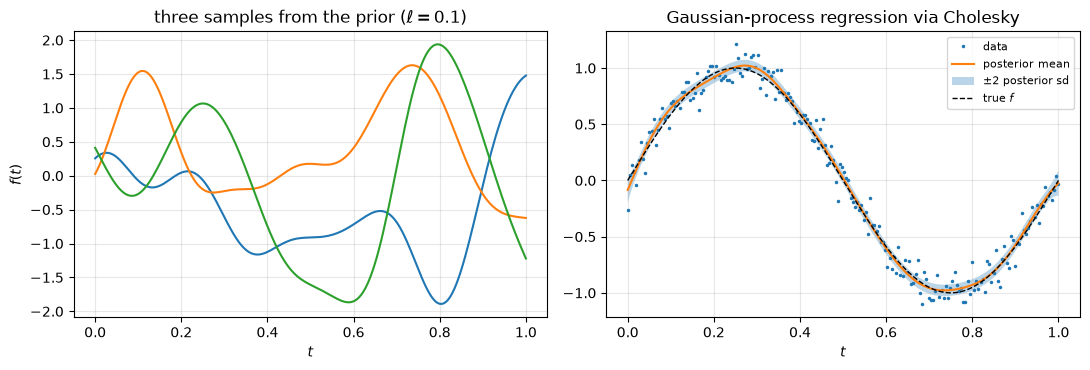

In [20]:
L_y = np.linalg.cholesky(K_y)
a = sla.cho_solve((L_y, True), y)
t_star = np.linspace(0, 1, 400)
K_star = np.exp(-(t[:, None] - t_star[None, :])**2 / (2 * 0.1**2))
mean = K_star.T @ a
V = sla.solve_triangular(L_y, K_star, lower=True)
var = 1.0 - np.sum(V**2, axis=0)
L_prior = np.linalg.cholesky(K + 1e-8 * np.eye(n))
samples = L_prior @ rng.standard_normal((n, 3))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(t, samples)
axes[0].set_title(r"three samples from the prior ($\ell = 0.1$)")
axes[0].set_xlabel("$t$")
axes[0].set_ylabel("$f(t)$")
axes[1].plot(t, y, ".", ms=3, label="data")
axes[1].plot(t_star, mean, label="posterior mean")
axes[1].fill_between(t_star, mean - 2 * np.sqrt(np.maximum(var, 0)), mean + 2 * np.sqrt(np.maximum(var, 0)),
                     alpha=0.3, label=r"$\pm 2$ posterior sd")
axes[1].plot(t_star, np.sin(2 * np.pi * t_star), "k--", lw=1, label=r"true $f$")
axes[1].set_title("Gaussian-process regression via Cholesky")
axes[1].set_xlabel("$t$")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

Sampling is correct in distribution: the sample covariance of $N$ draws
$Lw$ converges to $K$. Its expected squared Frobenius error is
$\sum_{i,j}(k_{ij}^2+k_{ii}k_{jj})/N\le2\operatorname{trace}(K)^2/N$.

In [21]:
m = 40
K_small = se_kernel(np.linspace(0, 1, m), 0.2) + 1e-8 * np.eye(m)
L_small = np.linalg.cholesky(K_small)
for N in (100, 1000, 10000, 100000):
    Y = L_small @ rng.standard_normal((m, N))
    err = np.linalg.norm(Y @ Y.T / N - K_small, "fro")
    rms = np.sqrt(2 / N) * np.trace(K_small)
    print(f"N = {N:6d}: ||C_N - K||_F = {err:.4f}   (sqrt(2/N) trace K = {rms:.4f})")
    assert err < 5 * rms          # Chebyshev: probability of exceeding 5 x RMS bound is below 1/25

N =    100: ||C_N - K||_F = 4.4497   (sqrt(2/N) trace K = 5.6569)
N =   1000: ||C_N - K||_F = 1.4000   (sqrt(2/N) trace K = 1.7889)
N =  10000: ||C_N - K||_F = 0.6097   (sqrt(2/N) trace K = 0.5657)
N = 100000: ||C_N - K||_F = 0.1168   (sqrt(2/N) trace K = 0.1789)


## 9. Iterative refinement

### 9.1 Fixed precision repairs the componentwise backward error

The componentwise backward error
$\omega(\hat x) = \max_i |b - A\hat x|_i / (|A||\hat x| + |b|)_i$ measures
perturbations relative to the individual entries of $A$ and $b$. Cholesky
guarantees small errors only relative to $|\widehat L||\widehat L^T|$,
which is nonzero where $A$ has zeros (fill-in). For the two-dimensional
Laplacian and a solution whose entries range over ten orders of magnitude,
$\omega$ is large; one step of refinement in the same precision
(Skeel, 1980) brings it down to the level of $u$.

In [22]:
def omega(A, x, b):
    """Componentwise (Oettli-Prager) backward error."""
    r = b - A @ x
    return np.max(np.abs(r) / (np.abs(A) @ np.abs(x) + np.abs(b)))


A = laplacian_2d(20)
n = A.shape[0]
x = rng.standard_normal(n) * 10.0 ** rng.uniform(-10, 0, n)
b = A @ x
fac = sla.cho_factor(A)
xh = sla.cho_solve(fac, b)
omegas = [omega(A, xh, b)]
for _ in range(3):
    xh = xh + sla.cho_solve(fac, b - A @ xh)
    omegas.append(omega(A, xh, b))
print("omega / u after 0, 1, 2, 3 refinement steps:", [f"{w / u:.2e}" for w in omegas])
# After one step the componentwise backward error is O(u) (Skeel); allow a constant of 10.
assert omegas[1] < 10 * u and omegas[0] > omegas[1]

omega / u after 0, 1, 2, 3 refinement steps: ['3.99e+05', '1.80e+00', '1.99e+00', '2.00e+00']


### 9.2 Low-precision factorization, working-precision residuals

Now the factorization is done in binary32 ($u_{32}\approx6\times10^{-8}$)
and the residuals and updates in binary64. By
[Theorem 6.7](https://aalsammani.github.io/numerical-linear-algebra/ch06-cholesky/notes.html#ch06-thm-refinement) the contraction factor is roughly
$\kappa(A)u_{32}$, so we expect convergence for $\kappa_2\lesssim10^7$ and
failure beyond. The residual is scaled before it is rounded to binary32, and
computed with the binary64 matrix.

kappa = 1e+02 (kappa u32 = 6.0e-06): error 1.9e-06 -> 3.9e-15; binary64 Cholesky solve: 3.4e-15
kappa = 1e+04 (kappa u32 = 6.0e-04): error 8.1e-05 -> 1.5e-13; binary64 Cholesky solve: 1.2e-13
kappa = 1e+06 (kappa u32 = 6.0e-02): error 4.6e-03 -> 6.7e-12; binary64 Cholesky solve: 6.0e-12
kappa = 1e+07 (kappa u32 = 6.0e-01): error 3.8e-02 -> 3.8e-11; binary64 Cholesky solve: 6.0e-11
kappa = 1e+08 (kappa u32 = 6.0e+00): error 6.8e-01 -> 3.9e-03; binary64 Cholesky solve: 6.7e-10
kappa = 1e+10 (kappa u32 = 6e+02): binary32 Cholesky fails


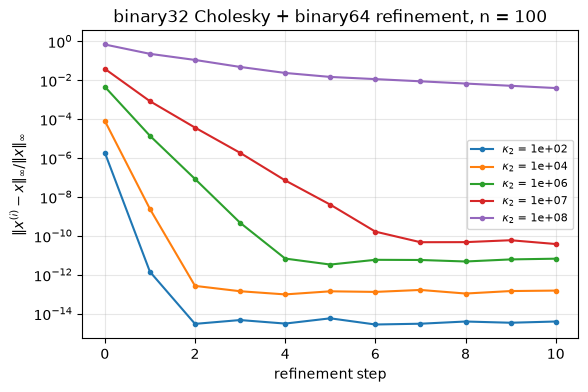

In [23]:
def refine_float32(A, b, iters=10):
    """Cholesky in binary32, residual and update in binary64. Returns list of iterates (or None)."""
    try:
        c32 = sla.cho_factor(A.astype(np.float32))
    except np.linalg.LinAlgError:
        return None
    x = sla.cho_solve(c32, b.astype(np.float32)).astype(np.float64)
    xs = [x]
    for _ in range(iters):
        r = b - A @ x                                   # binary64 residual with the binary64 matrix
        s = np.linalg.norm(r, np.inf)
        if s > 0:
            x = x + s * sla.cho_solve(c32, (r / s).astype(np.float32)).astype(np.float64)
        xs.append(x)
    return xs


n = 100
fig, ax = plt.subplots()
for kappa in (1e2, 1e4, 1e6, 1e7, 1e8, 1e10):
    A = random_spd(n, kappa, rng)
    x = rng.standard_normal(n)
    b = A @ x
    xs = refine_float32(A, b)
    e64 = np.linalg.norm(sla.cho_solve(sla.cho_factor(A), b) - x, np.inf) / np.linalg.norm(x, np.inf)
    if xs is None:
        print(f"kappa = {kappa:.0e} (kappa u32 = {kappa * u32:.0e}): binary32 Cholesky fails")
        continue
    errs = [np.linalg.norm(xi - x, np.inf) / np.linalg.norm(x, np.inf) for xi in xs]
    ax.semilogy(errs, "o-", ms=3, label=rf"$\kappa_2$ = {kappa:.0e}")
    print(f"kappa = {kappa:.0e} (kappa u32 = {kappa * u32:.1e}): error {errs[0]:.1e} -> {errs[-1]:.1e}; "
          f"binary64 Cholesky solve: {e64:.1e}")
    if kappa * u32 < 0.1:
        # converged to the accuracy of a backward stable binary64 solve: forward error
        # at most about kappa * n * gamma_{3n+1} (backward error theorem of the notes);
        # the rounding error in b itself adds at most a factor 2.
        assert errs[-1] < 2 * kappa * n * gamma(3 * n + 1)
ax.set_xlabel("refinement step")
ax.set_ylabel(r"$\|x^{(i)} - x\|_\infty / \|x\|_\infty$")
ax.set_title("binary32 Cholesky + binary64 refinement, n = 100")
ax.legend(fontsize=8)
plt.show()

For $\kappa_2u_{32}\ll1$ the error drops by roughly a factor $\kappa_2u_{32}$
per step until it reaches the accuracy of a binary64 Cholesky solve. At
$\kappa_2 = 10^7$ ($\kappa_2u_{32}\approx0.6$) convergence is slow; at
$10^8$ ($\kappa_2u_{32}\approx6$) there is no guarantee of contraction, and
the iteration may stagnate, make slow and erratic progress, or diverge (it diverges for the matrix of
[Figure 6.3](https://aalsammani.github.io/numerical-linear-algebra/ch06-cholesky/notes.html#ch06-fig-refinement) in the notes), and it stays far from the accuracy of a
binary64 solve; at $10^{10}$ the binary32 matrix is not even positive
definite. With residuals in
binary64 the limiting accuracy is that of a binary64 solve: the benefit of
this scheme is speed (the $\mathcal{O}(n^3)$ work is done in the faster
precision), not extra accuracy.

### 9.3 Extra-precise residuals

To see refinement beat $\kappa u$, the residual must be computed more
accurately than the working precision (Moler, 1967). Without a
quadruple-precision type we can compute $b - A\hat x$ *exactly* and round it
once: every product $a_{ij}\hat x_j$ is the exact sum of two doubles
(Dekker's splitting), and `math.fsum` adds a list of doubles with a single
rounding. We check this against rational arithmetic.

In [24]:
def two_prod(a, b):
    """p = fl(a*b) and e such that a*b = p + e exactly (barring overflow/underflow)."""
    p = a * b
    f = 134217729.0                                    # 2**27 + 1
    c = f * a
    ah = c - (c - a)
    al = a - ah
    c = f * b
    bh = c - (c - b)
    bl = b - bh
    e = ((ah * bh - p) + ah * bl + al * bh) + al * bl
    return p, e


def residual_exact(A, x, b):
    """b - A x computed exactly and rounded once to binary64."""
    P, E = two_prod(A, x[None, :])
    return np.array([math.fsum(np.concatenate(([b[i]], -P[i], -E[i]))) for i in range(A.shape[0])])


A_t, x_t, b_t = rng.standard_normal((6, 6)), rng.standard_normal(6), rng.standard_normal(6)
r_exact = [float(Fraction(b_t[i]) - sum(Fraction(A_t[i, j]) * Fraction(x_t[j]) for j in range(6))) for i in range(6)]
assert np.array_equal(residual_exact(A_t, x_t, b_t), np.array(r_exact))
print("residual_exact agrees with rational arithmetic")

residual_exact agrees with rational arithmetic


The scaled Hilbert matrix $\operatorname{lcm}(1,\dots,2n-1)\,H_n$ has integer
entries, so for an integer vector $x$ the right-hand side $b = Hx$ is exact
and $x$ is the exact solution of the stored system.

In [25]:
def scaled_hilbert(n):
    c = math.lcm(*range(1, 2 * n))
    return np.array([[c // (i + j + 1) for j in range(n)] for i in range(n)], dtype=float)


for n in (8, 10, 11):
    H = scaled_hilbert(n)
    x = rng.integers(-9, 10, n).astype(float)
    b_int = [sum(int(H[i, j]) * int(x[j]) for j in range(n)) for i in range(n)]
    assert max(abs(v) for v in b_int) < 2**53           # b is exact in binary64
    b = np.array(b_int, dtype=float)
    fac = sla.cho_factor(H)
    xe = xw = sla.cho_solve(fac, b)
    err0 = np.linalg.norm(xe - x, np.inf) / np.linalg.norm(x, np.inf)
    for _ in range(8):
        xe = xe + sla.cho_solve(fac, residual_exact(H, xe, b))
        xw = xw + sla.cho_solve(fac, b - H @ xw)
    ee = np.linalg.norm(xe - x, np.inf) / np.linalg.norm(x, np.inf)
    ew = np.linalg.norm(xw - x, np.inf) / np.linalg.norm(x, np.inf)
    print(f"n = {n:2d}, kappa_2 = {np.linalg.cond(H):.1e}: initial error {err0:.1e}; after 8 steps: "
          f"exact residuals {ee:.1e}, binary64 residuals {ew:.1e}")
    assert ee <= u                                     # kappa u < 1: converges to working accuracy

n =  8, kappa_2 = 1.5e+10: initial error 1.5e-08; after 8 steps: exact residuals 2.9e-68, binary64 residuals 8.9e-08
n = 10, kappa_2 = 1.6e+13: initial error 7.1e-05; after 8 steps: exact residuals 0.0e+00, binary64 residuals 5.3e-05
n = 11, kappa_2 = 5.2e+14: initial error 1.4e-03; after 8 steps: exact residuals 0.0e+00, binary64 residuals 3.7e-03


With exactly rounded residuals the iteration recovers the integer solution
to full working accuracy (usually exactly), even for $\kappa_2\approx5\times10^{14}$;
with binary64 residuals it stays at about the error of the initial solve,
below $\kappa_2u$.

## 10. Condition estimation

Computing $\|A^{-1}\|_1$ exactly needs $A^{-1}$. Hager's method
([Algorithm 6.4](https://aalsammani.github.io/numerical-linear-algebra/ch06-cholesky/notes.html#ch06-alg-hager)) estimates it from a few solves with the existing
factors. We implement it and reproduce [Example 6.6](https://aalsammani.github.io/numerical-linear-algebra/ch06-cholesky/notes.html#ch06-exa-hager).

In [26]:
def hager(apply_B, apply_BT, n, itmax=5):
    """Hager's lower-bound estimate of ||B||_1 from products with B and B^T. Returns (estimate, iterations)."""
    x = np.full(n, 1.0 / n)
    for k in range(1, itmax + 1):
        y = apply_B(x)
        est = np.linalg.norm(y, 1)
        xi = np.where(y >= 0, 1.0, -1.0)               # sign(y) with sign(0) = 1
        z = apply_BT(xi)
        j = int(np.argmax(np.abs(z)))
        if abs(z[j]) <= z @ x:                          # local optimality test
            return est, k
        x = np.zeros(n)
        x[j] = 1.0
    return est, itmax


A2 = np.array([[4.0, 2.0], [2.0, 2.0]])
f2 = sla.cho_factor(A2)
est2, its2 = hager(lambda v: sla.cho_solve(f2, v), lambda v: sla.cho_solve(f2, v), 2)
print(f"2x2 example: estimate {est2}, iterations {its2}, exact {np.linalg.norm(np.linalg.inv(A2), 1)}")
assert est2 == 1.5

2x2 example: estimate 1.5, iterations 2, exact 1.5


Now a comparison on random matrices with the exact norm, with LAPACK's
`dpocon` (SPD, from the Cholesky factor) and `dgecon` (general, from LU),
and with SciPy's block estimator `onenormest` applied to a linear operator
that performs solves.

In [27]:
n = 100
rows = []
for trial in range(30):
    B = rng.standard_normal((n, n))
    A = B @ B.T + 10.0 ** rng.uniform(-6, 0) * np.eye(n)
    anorm = np.linalg.norm(A, 1)
    c_up, info = sla.lapack.dpotrf(A)
    assert info == 0
    solve = lambda v: sla.cho_solve((c_up, False), v)
    exact = np.linalg.norm(np.linalg.inv(A), 1)
    est_h, _ = hager(solve, solve, n)
    rcond, info = sla.lapack.dpocon(c_up, anorm)
    op = LinearOperator((n, n), matvec=solve, rmatvec=solve, dtype=float)
    rows.append((est_h / exact, 1 / (rcond * anorm) / exact, onenormest(op) / exact, np.linalg.cond(A, 1)))
rows = np.array(rows)
print("ratio estimate / exact for 30 SPD matrices (min, median):")
for name, col in zip(("Hager (ours)", "LAPACK dpocon", "onenormest"), rows[:, :3].T):
    print(f"  {name:14s} min {col.min():.3f}, median {np.median(col):.3f}")
# Estimates are lower bounds; the computed "exact" value itself has relative error about kappa_1 u.
assert np.all(rows[:, :3] <= 1 + 10 * n * rows[:, 3:4] * u)

A = rng.standard_normal((n, n))
lu_piv = sla.lu_factor(A)
rcond, info = sla.lapack.dgecon(lu_piv[0], np.linalg.norm(A, 1))
print(f"general matrix: kappa_1 estimate from dgecon {1 / rcond:.4e}, exact {np.linalg.cond(A, 1):.4e}")

ratio estimate / exact for 30 SPD matrices (min, median):
  Hager (ours)   min 0.864, median 1.000
  LAPACK dpocon  min 0.864, median 1.000
  onenormest     min 0.873, median 1.000
general matrix: kappa_1 estimate from dgecon 2.4136e+04, exact 2.4136e+04


**Cost.** Given the factors, an estimate costs a handful of triangular
solves, $\mathcal{O}(n^2)$ flops, whereas forming the inverse costs
$\mathcal{O}(n^3)$. We apply the factor with `solve_triangular` directly,
because a call of `cho_solve` for a single vector has an overhead that is
large compared with the $2n^2$ flops of the two triangular solves. The
timings below are observations on this machine.

In [28]:
n = 1500
B = rng.standard_normal((n, n))
A = B @ B.T + n * np.eye(n)
L = np.linalg.cholesky(A)


def solve_spd(V):
    """A^{-1} V with A = L L^T: forward then back substitution."""
    W = sla.solve_triangular(L, V, lower=True, check_finite=False)
    return sla.solve_triangular(L, W, lower=True, trans="T", check_finite=False)


t_fac = median_time(np.linalg.cholesky, A, repeats=5)
t_est = median_time(lambda: hager(solve_spd, solve_spd, n), repeats=5)
t_inv = median_time(solve_spd, np.eye(n), repeats=5)
est, its = hager(solve_spd, solve_spd, n)
print(f"n = {n}: factorization {t_fac * 1e3:.1f} ms, Hager estimate ({its} iterations, {2 * its} solves) "
      f"{t_est * 1e3:.2f} ms, inverse from the factors {t_inv * 1e3:.1f} ms")

n = 1500: factorization 36.9 ms, Hager estimate (2 iterations, 4 solves) 1.47 ms, inverse from the factors 37.8 ms


## Common mistakes

- Using `scipy.linalg.cholesky(A)` as if it returned the lower factor (it
  returns $R = L^T$), or using the matrix `c` of `cho_factor` directly as the
  factor.
- Assuming that a Cholesky routine checks symmetry. It reads one triangle.
- Believing $|\ell_{ij}|\le\ell_{jj}$; the correct bound is
  $|\ell_{ij}|\le\sqrt{a_{ii}}$.
- Computing $\log\det A$ as `np.log(np.linalg.det(A))`, which overflows or
  underflows; use $2\sum\log\ell_{ii}$ or `slogdet`.
- Forming $K^{-1}$ to evaluate $y^TK^{-1}y$ or a posterior mean.
- Adding a jitter without reporting it or checking its effect.
- In mixed-precision refinement, computing the residual with the rounded
  low-precision matrix, or not scaling the residual before rounding it.
- Computing `np.linalg.cond(A, 1)` (which forms $A^{-1}$) just to get an
  error bound, when an estimate from the factors is available.
- Reporting a timing ratio as a law of nature.

## Your turn

1. Modify `cholesky` into the right-looking (outer-product) form that
   updates the Schur complement at every step, verify it against the
   column-oriented version, and time both for $n = 500$.
2. Implement the square-root-free $LDL^T$ factorization for SPD matrices and
   count its flops ([Exercise 6.4](https://aalsammani.github.io/numerical-linear-algebra/ch06-cholesky/notes.html#ch06-ex-flops)).
3. Implement a function that returns the certificate vector $z$ of
   [Theorem 6.5](https://aalsammani.github.io/numerical-linear-algebra/ch06-cholesky/notes.html#ch06-thm-test-pd) when Cholesky fails, and test it on
   $T_n - \sigma I$ for several shifts $\sigma$.
4. Repeat the experiment of Section 9.2 with residuals computed by
   `residual_exact`. What is the limiting accuracy now?
5. Use `onenormest` to estimate $\kappa_1$ for the two-dimensional
   Laplacian with $m = 100$ ($n = 10^4$) using a banded Cholesky
   factorization (`scipy.linalg.cholesky_banded` and `cho_solve_banded`),
   without ever forming a dense matrix.

## Key takeaways

- An SPD matrix has a unique Cholesky factor, computed in $\tfrac13n^3$
  flops without pivoting; its entries satisfy $|\ell_{ij}|\le\sqrt{a_{ii}}$.
- Cholesky is backward stable whenever it completes; the forward error of
  the solution still grows like $\kappa_2(A)u$.
- Cholesky decides positive definiteness, but it assumes symmetry, and a
  nearly singular SPD matrix may be indefinite once it is stored.
- The Cholesky factor gives log-determinants, samples and posterior means
  of Gaussian models; jitter controls the conditioning of kernel matrices.
- Iterative refinement reuses the factors: in fixed precision it fixes the
  componentwise backward error, with a low-precision factorization it
  converges when $\kappa u_f$ is small, and with extra-precise residuals it
  delivers full working accuracy.
- Condition numbers are estimated, not computed, in $\mathcal{O}(n^2)$ flops.

## Further reading

Trefethen and Bau (1997), Lecture 23; Golub and Van Loan (2013), Sections 4.1,
4.2, 4.4 and 3.5; Higham (2002), Chapters 10, 11, 12 and 15;
Carson and Higham (2018) for refinement in three precisions; and
Rasmussen and Williams (2006), Chapter 2, for Gaussian-process regression.